In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



In [2]:
data_path = Path('/home/mini/projects/churn-clv-prediction-suite/data/raw/online_retail_II.xlsx')
df_2009 = pd.read_excel(data_path, sheet_name='Year 2009-2010')
df_2010 = pd.read_excel(data_path, sheet_name='Year 2010-2011')

df = pd.concat([df_2009, df_2010], ignore_index=True)


print(f"\nSheet 1 rows: {len(df_2009):,}")
print(f"Sheet 2 rows: {len(df_2010):,}")
print(f"Combined: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)



Sheet 1 rows: 525,461
Sheet 2 rows: 541,910
Combined: 1,067,371

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [ ]:
df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
print("Dtypes after fix:")
print(df.dtypes)
print(f"\nInvoice samples (showing 'C' prefixes):")
print(df['Invoice'].sample(5).tolist())



Dtypes after fix:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Invoice samples (showing 'C' prefixes):
['536196', '521792', '510772', 'C552863', '525054']


In [8]:
output_path = "/home/mini/projects/churn-clv-prediction-suite/data/raw/online_retail_II_combined.parquet"

df.to_parquet(output_path, index=False)
print(f"Saved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")

ArrowTypeError: ("Expected bytes, got a 'int' object", 'Conversion failed for column Description with type object')

In [9]:
non_string_desc = df[df['Description'].apply(lambda x: not isinstance(x, str) and pd.notna(x))]
print(f"Non-string Description rows: {len(non_string_desc):,}")
print(f"\nSample types found:")
print(df['Description'].apply(lambda x: type(x).__name__).value_counts())
print(f"\nSample non-string descriptions:")
print(non_string_desc.head(10))


Non-string Description rows: 4

Sample types found:
Description
str      1062985
float       4382
int            4
Name: count, dtype: int64

Sample non-string descriptions:
       Invoice StockCode Description  Quantity         InvoiceDate  Price  \
6911    490007     84347       21494      -720 2009-12-03 12:09:00    0.0   
274052  516016     22467       22719         2 2010-07-16 10:11:00    0.0   
274053  516017     22719       22467        -2 2010-07-16 10:11:00    0.0   
945851  572891     23343       20713      -400 2011-10-26 14:14:00    0.0   

        Customer ID         Country  
6911            NaN  United Kingdom  
274052          NaN  United Kingdom  
274053          NaN  United Kingdom  
945851          NaN  United Kingdom  


In [10]:
df['Description'] = df['Description'].astype(str)
print(df['Description'].apply(lambda x: type(x).__name__).value_counts())


Description
str    1067371
Name: count, dtype: int64


In [11]:
output_path = "/home/mini/projects/churn-clv-prediction-suite/data/raw/online_retail_II_combined.parquet"
df.to_parquet(output_path, index=False)
print(f"Saved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")


Saved to /home/mini/projects/churn-clv-prediction-suite/data/raw/online_retail_II_combined.parquet
File size: 6.9 MB


In [12]:
print(f"Shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nMissing % per column:")
print((df.isnull().sum() / len(df) * 100).round(2))


Shape: (1067371, 8)

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing values per column:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing % per column:
Invoice         0.00
StockCode       0.00
Description     0.00
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64


In [13]:
print(df.describe())


           Quantity                    InvoiceDate         Price  \
count  1.067371e+06                        1067371  1.067371e+06   
mean   9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min   -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   
25%    1.000000e+00            2010-07-09 09:46:00  1.250000e+00   
50%    3.000000e+00            2010-12-07 15:28:00  2.100000e+00   
75%    1.000000e+01            2011-07-22 10:23:00  4.150000e+00   
max    8.099500e+04            2011-12-09 12:50:00  3.897000e+04   
std    1.727058e+02                            NaN  1.235531e+02   

         Customer ID  
count  824364.000000  
mean    15324.638504  
min     12346.000000  
25%     13975.000000  
50%     15255.000000  
75%     16797.000000  
max     18287.000000  
std      1697.464450  


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Earliest date: {df['InvoiceDate'].min()}")
print(f"Latest date:   {df['InvoiceDate'].max()}")
print(f"Total days:    {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days}")

df['year_month'] = df['InvoiceDate'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()
print(f"\nMonthly transaction counts:")
print(monthly_counts)

Earliest date: 2009-12-01 07:45:00
Latest date:   2011-12-09 12:50:00
Total days:    738

Monthly transaction counts:
year_month
2009-12    45228
2010-01    31555
2010-02    29388
2010-03    41511
2010-04    34057
2010-05    35323
2010-06    39983
2010-07    33383
2010-08    33306
2010-09    42091
2010-10    59098
2010-11    78015
2010-12    65004
2011-01    35147
2011-02    27707
2011-03    36748
2011-04    29916
2011-05    37030
2011-06    36874
2011-07    39518
2011-08    35284
2011-09    50226
2011-10    60742
2011-11    84711
2011-12    25526
Freq: M, dtype: int64


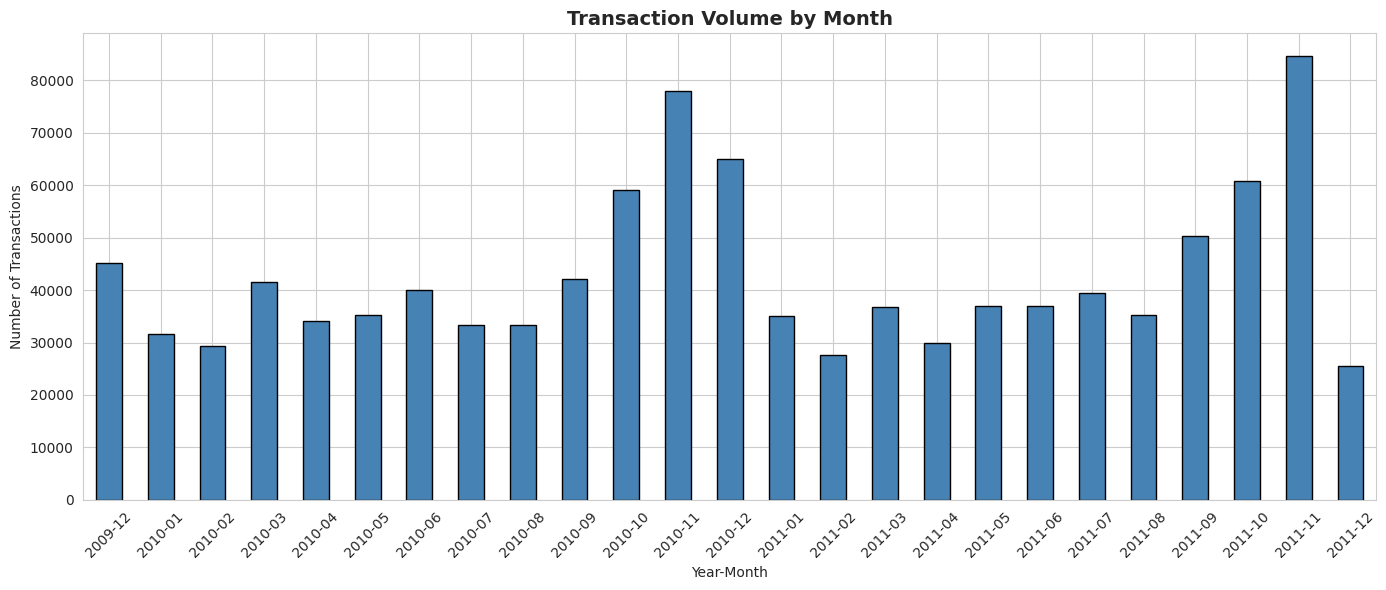

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
monthly_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Transaction Volume by Month', fontweight='bold', fontsize=14)
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of Transactions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/06_retail_temporal_pattern.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
country_counts = df['Country'].value_counts()
print(f"Total countries: {df['Country'].nunique()}")
print(f"\nTop 10 countries by transaction count:")
print(country_counts.head(10))

print(f"\nUK percentage: {(country_counts['United Kingdom'] / len(df) * 100):.2f}%")

Total countries: 43

Top 10 countries by transaction count:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

UK percentage: 91.94%


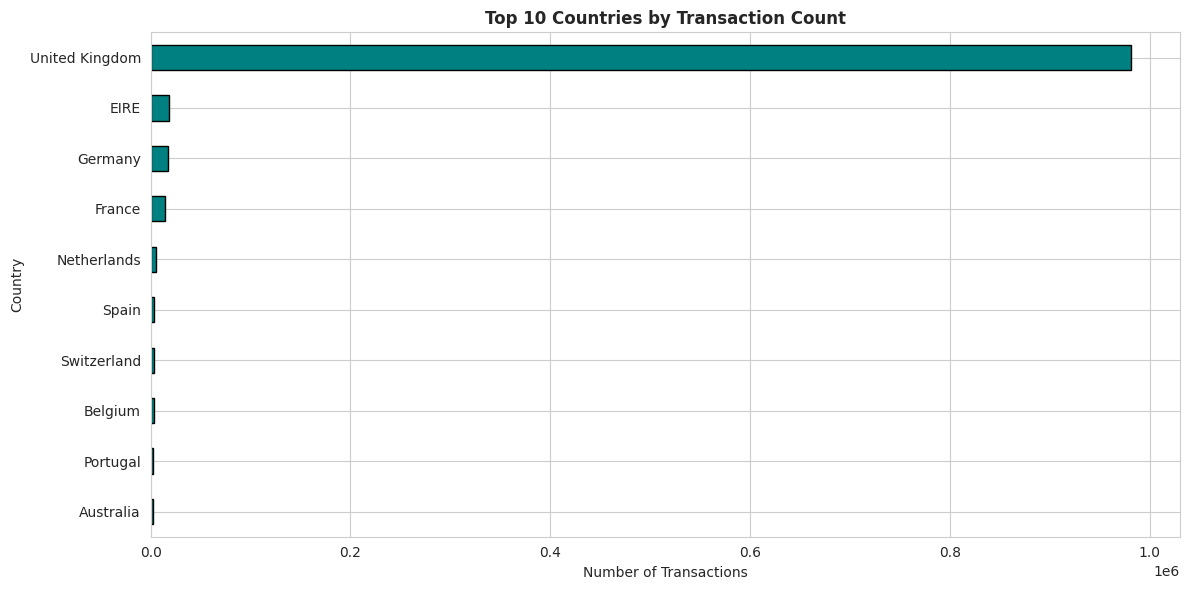

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
country_counts.head(10).plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_title('Top 10 Countries by Transaction Count', fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/07_retail_country_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [18]:
df['Invoice'] = df['Invoice'].astype(str)
df['is_cancellation'] = df['Invoice'].str.startswith('C')

cancellation_count = df['is_cancellation'].sum()
print(f"Cancellations (Invoice starting with 'C'): {cancellation_count:,} ({cancellation_count/len(df)*100:.2f}%)")

negative_qty = (df['Quantity'] < 0).sum()
zero_qty = (df['Quantity'] == 0).sum()
print(f"Negative quantity rows (returns): {negative_qty:,} ({negative_qty/len(df)*100:.2f}%)")
print(f"Zero quantity rows: {zero_qty:,}")

negative_price = (df['Price'] < 0).sum()
zero_price = (df['Price'] == 0).sum()
print(f"Negative price rows: {negative_price:,}")
print(f"Zero price rows: {zero_price:,}")

both = ((df['Quantity'] < 0) & df['is_cancellation']).sum()
print(f"\nRows with BOTH negative qty AND 'C' invoice: {both:,}")
print(f"This is {both/cancellation_count*100:.1f}% of cancellations")

Cancellations (Invoice starting with 'C'): 19,494 (1.83%)
Negative quantity rows (returns): 22,950 (2.15%)
Zero quantity rows: 0
Negative price rows: 5
Zero price rows: 6,202

Rows with BOTH negative qty AND 'C' invoice: 19,493
This is 100.0% of cancellations


In [19]:
nan_customer = df['Customer ID'].isnull().sum()
unique_customers = df['Customer ID'].nunique()
print(f"Transactions without Customer ID: {nan_customer:,} ({nan_customer/len(df)*100:.2f}%)")
print(f"Unique customers (excluding NaN): {unique_customers:,}")

print(f"\nSample of anonymous transactions:")
print(df[df['Customer ID'].isnull()].head(5)[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Country']])

print(f"\nCountry distribution — anonymous:")
print(df[df['Customer ID'].isnull()]['Country'].value_counts().head(5))
print(f"\nCountry distribution — identified:")
print(df[df['Customer ID'].notnull()]['Country'].value_counts().head(5))

Transactions without Customer ID: 243,007 (22.77%)
Unique customers (excluding NaN): 5,942

Sample of anonymous transactions:
    Invoice StockCode                Description  Quantity  Price  \
263  489464     21733               85123a mixed       -96   0.00   
283  489463     71477                      short      -240   0.00   
284  489467    85123A                21733 mixed      -192   0.00   
470  489521     21646                        nan       -50   0.00   
577  489525    85226C  BLUE PULL BACK RACING CAR         1   0.55   

            Country  
263  United Kingdom  
283  United Kingdom  
284  United Kingdom  
470  United Kingdom  
577  United Kingdom  

Country distribution — anonymous:
Country
United Kingdom    240029
EIRE                1671
Hong Kong            364
Unspecified          232
France               128
Name: count, dtype: int64

Country distribution — identified:
Country
United Kingdom    741301
Germany            17624
EIRE               16195
France        

In [20]:
df_clean = df[df['Customer ID'].notnull() & ~df['is_cancellation']].copy()
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

customer_stats = df_clean.groupby('Customer ID').agg(
    total_transactions=('Invoice', 'nunique'),
    total_items_purchased=('Quantity', 'sum'),
    total_spent=('TotalAmount', 'sum'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
).reset_index()

customer_stats['customer_lifetime_days'] = (
    customer_stats['last_purchase'] - customer_stats['first_purchase']
).dt.days

print(f"Total unique customers: {len(customer_stats):,}")
print(f"\nTransaction count statistics:")
print(customer_stats['total_transactions'].describe())
print(f"\nTotal spend statistics (£):")
print(customer_stats['total_spent'].describe())
print(f"\nCustomer lifetime statistics (days):")
print(customer_stats['customer_lifetime_days'].describe())

Total unique customers: 5,881

Transaction count statistics:
count    5881.000000
mean        6.287196
std        13.012879
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: total_transactions, dtype: float64

Total spend statistics (£):
count      5881.000000
mean       3017.076888
std       14734.128619
min           0.000000
25%         347.800000
50%         897.620000
75%        2304.180000
max      608821.650000
Name: total_spent, dtype: float64

Customer lifetime statistics (days):
count    5881.000000
mean      272.883183
std       258.815005
min         0.000000
25%         0.000000
50%       220.000000
75%       511.000000
max       738.000000
Name: customer_lifetime_days, dtype: float64


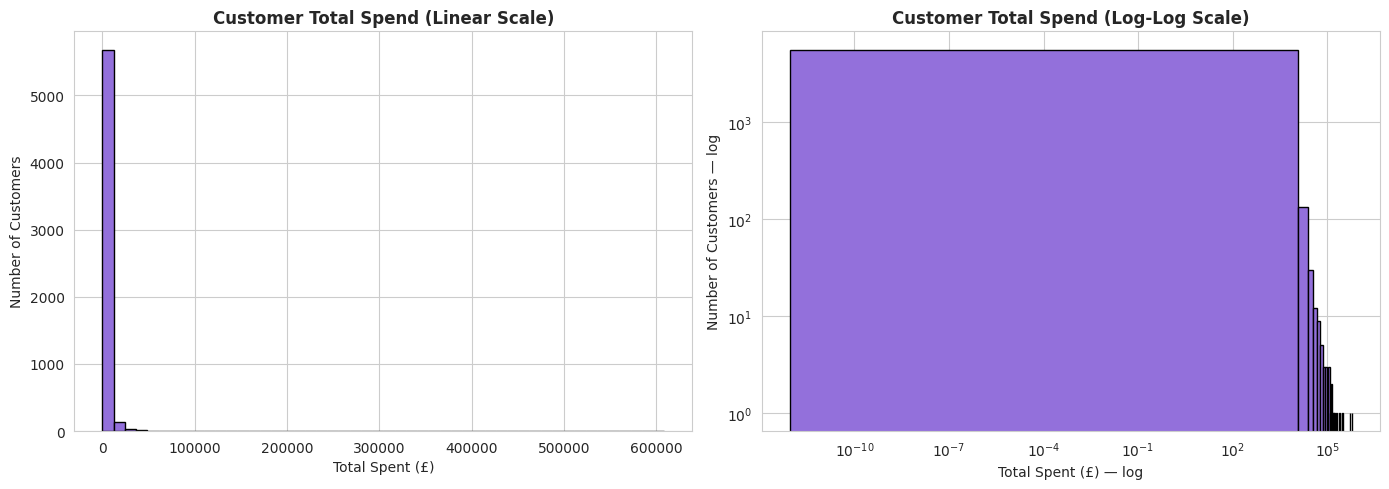


Pareto Analysis:
  Top  5% of customers (294) generate 52.0% of revenue
  Top 10% of customers (588) generate 63.9% of revenue
  Top 20% of customers (1,176) generate 77.3% of revenue


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(customer_stats['total_spent'], bins=50, color='mediumpurple', edgecolor='black')
axes[0].set_title('Customer Total Spend (Linear Scale)', fontweight='bold')
axes[0].set_xlabel('Total Spent (£)')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(customer_stats['total_spent'], bins=50, color='mediumpurple', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Customer Total Spend (Log-Log Scale)', fontweight='bold')
axes[1].set_xlabel('Total Spent (£) — log')
axes[1].set_ylabel('Number of Customers — log')

plt.tight_layout()
plt.savefig('../reports/figures/08_retail_customer_spend_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

sorted_spend = customer_stats['total_spent'].sort_values(ascending=False)
top_20pct_count = int(len(sorted_spend) * 0.2)
top_20pct_revenue_share = sorted_spend.head(top_20pct_count).sum() / sorted_spend.sum() * 100
top_10pct_count = int(len(sorted_spend) * 0.1)
top_10pct_revenue_share = sorted_spend.head(top_10pct_count).sum() / sorted_spend.sum() * 100
top_5pct_count = int(len(sorted_spend) * 0.05)
top_5pct_revenue_share = sorted_spend.head(top_5pct_count).sum() / sorted_spend.sum() * 100

print(f"\nPareto Analysis:")
print(f"  Top  5% of customers ({top_5pct_count:,}) generate {top_5pct_revenue_share:.1f}% of revenue")
print(f"  Top 10% of customers ({top_10pct_count:,}) generate {top_10pct_revenue_share:.1f}% of revenue")
print(f"  Top 20% of customers ({top_20pct_count:,}) generate {top_20pct_revenue_share:.1f}% of revenue")

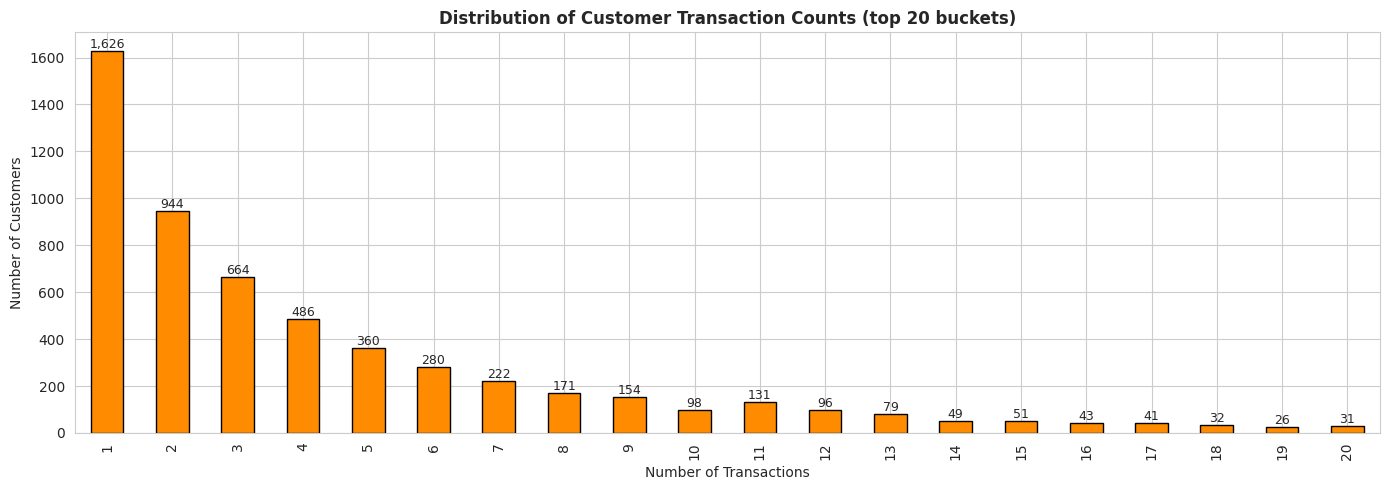


Single-purchase customers: 1,626 (27.6%)
Repeat customers: 4,255 (72.4%)
Average transactions per repeat customer: 8.31


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

freq_dist = customer_stats['total_transactions'].value_counts().sort_index()
freq_dist.head(20).plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Distribution of Customer Transaction Counts (top 20 buckets)', fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Number of Customers')

for i, v in enumerate(freq_dist.head(20).values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/09_retail_transaction_frequency.png', dpi=100, bbox_inches='tight')
plt.show()

single_purchase = (customer_stats['total_transactions'] == 1).sum()
print(f"\nSingle-purchase customers: {single_purchase:,} ({single_purchase/len(customer_stats)*100:.1f}%)")
print(f"Repeat customers: {len(customer_stats) - single_purchase:,} ({(len(customer_stats) - single_purchase)/len(customer_stats)*100:.1f}%)")
print(f"Average transactions per repeat customer: {customer_stats[customer_stats['total_transactions'] > 1]['total_transactions'].mean():.2f}")

Basket statistics:
       unique_items  total_quantity  invoice_total
count  36975.000000    36975.000000   36975.000000
mean      20.795808      289.950534     479.876381
std       22.399384     1237.460406    1374.892597
min        1.000000        1.000000       0.000000
25%        6.000000       73.000000     160.705000
50%       15.000000      155.000000     305.220000
75%       27.000000      292.000000     489.195000
max      541.000000    87167.000000  168469.600000


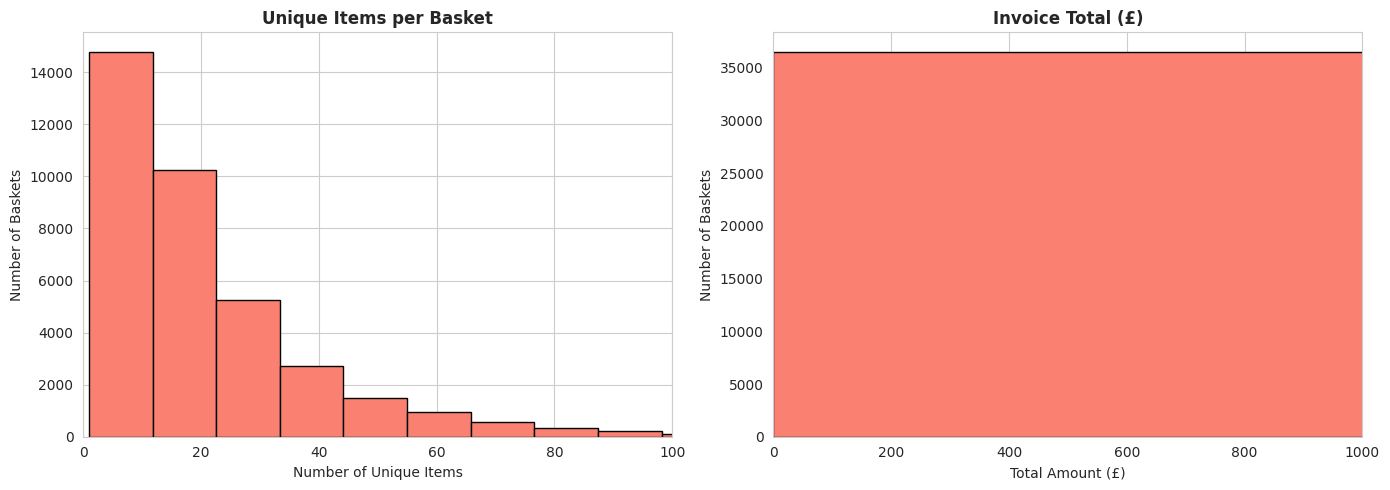

In [23]:
basket_size = df_clean.groupby('Invoice').agg(
    unique_items=('StockCode', 'nunique'),
    total_quantity=('Quantity', 'sum'),
    invoice_total=('TotalAmount', 'sum')
).reset_index()

print(f"Basket statistics:")
print(basket_size.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(basket_size['unique_items'], bins=50, color='salmon', edgecolor='black')
axes[0].set_title('Unique Items per Basket', fontweight='bold')
axes[0].set_xlabel('Number of Unique Items')
axes[0].set_ylabel('Number of Baskets')
axes[0].set_xlim(0, 100)  # most baskets are small

axes[1].hist(basket_size['invoice_total'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Invoice Total (£)', fontweight='bold')
axes[1].set_xlabel('Total Amount (£)')
axes[1].set_ylabel('Number of Baskets')
axes[1].set_xlim(0, 1000)  # most are under £1000

plt.tight_layout()
plt.savefig('../reports/figures/10_retail_basket_size.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
top_products = df_clean.groupby('Description').agg(
    total_quantity=('Quantity', 'sum'),
    total_revenue=('TotalAmount', 'sum'),
    unique_customers=('Customer ID', 'nunique'),
    transaction_count=('Invoice', 'nunique')
).sort_values('total_revenue', ascending=False)

print("Top 15 products by revenue:")
print(top_products.head(15))

print("\nTop 15 products by transaction count (popularity):")
print(top_products.sort_values('transaction_count', ascending=False).head(15))

Top 15 products by revenue:
                                     total_quantity  total_revenue  \
Description                                                          
REGENCY CAKESTAND 3 TIER                      24914      286486.30   
WHITE HANGING HEART T-LIGHT HOLDER            93640      252072.46   
PAPER CRAFT , LITTLE BIRDIE                   80995      168469.60   
Manual                                         9810      152340.57   
JUMBO BAG RED RETROSPOT                       75759      136980.08   
ASSORTED COLOUR BIRD ORNAMENT                 79913      127074.17   
POSTAGE                                        5333      126563.04   
PARTY BUNTING                                 23611      103880.23   
MEDIUM CERAMIC TOP STORAGE JAR                77916       81416.73   
PAPER CHAIN KIT 50'S CHRISTMAS                29477       79594.33   
CHILLI LIGHTS                                 15735       72860.14   
BLACK RECORD COVER FRAME                      19629       6720

In [25]:
print("="*70)
print("ONLINE RETAIL II — EDA SUMMARY")
print("="*70)

print(f"\nDataset Size:")
print(f"  Total transactions: {len(df):,}")
print(f"  Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"  Total days: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days}")
print(f"  Countries: {df['Country'].nunique()}")
print(f"  UK transactions: {(country_counts['United Kingdom'] / len(df) * 100):.1f}%")

print(f"\nData Quality Issues:")
print(f"  - Customer ID missing: {nan_customer:,} ({nan_customer/len(df)*100:.2f}%)")
print(f"  - Cancellations: {cancellation_count:,} ({cancellation_count/len(df)*100:.2f}%)")
print(f"  - Negative quantity: {negative_qty:,}")
print(f"  - Zero/negative price: {zero_price + negative_price:,}")
print(f"  - Description data quality: 4 integer values found (admin entries)")

print(f"\nAfter Cleaning:")
print(f"  Usable transactions: {len(df_clean):,}")
print(f"  Unique customers: {len(customer_stats):,}")

print(f"\nCustomer Behavior Insights:")
print(f"  - Single-purchase customers: {single_purchase/len(customer_stats)*100:.1f}%")
print(f"  - Top 5% generate {top_5pct_revenue_share:.1f}% of revenue (Pareto strong)")
print(f"  - Top 20% generate {top_20pct_revenue_share:.1f}% of revenue")
print(f"  - Median customer spend: £{customer_stats['total_spent'].median():.2f}")
print(f"  - Mean customer spend: £{customer_stats['total_spent'].mean():.2f}")
print(f"  - Median transaction count: {customer_stats['total_transactions'].median():.0f}")

print(f"\nNext Steps for Preprocessing:")
print(f"  1. Drop {nan_customer:,} NaN Customer ID rows")
print(f"  2. Drop {cancellation_count:,} cancellations")
print(f"  3. Drop {negative_qty:,} negative quantity rows")
print(f"  4. Drop {zero_price + negative_price:,} zero/negative price rows")
print(f"  5. Convert Customer ID to int")
print(f"  6. Compute TotalAmount = Quantity × Price")
print(f"  7. Create RFM features per customer")
print(f"  8. Apply BG/NBD + Gamma-Gamma for CLV")
print(f"  9. K-means / RFM-based segmentation")

ONLINE RETAIL II — EDA SUMMARY

Dataset Size:
  Total transactions: 1,067,371
  Date range: 2009-12-01 to 2011-12-09
  Total days: 738
  Countries: 43
  UK transactions: 91.9%

Data Quality Issues:
  - Customer ID missing: 243,007 (22.77%)
  - Cancellations: 19,494 (1.83%)
  - Negative quantity: 22,950
  - Zero/negative price: 6,207
  - Description data quality: 4 integer values found (admin entries)

After Cleaning:
  Usable transactions: 805,620
  Unique customers: 5,881

Customer Behavior Insights:
  - Single-purchase customers: 27.6%
  - Top 5% generate 52.0% of revenue (Pareto strong)
  - Top 20% generate 77.3% of revenue
  - Median customer spend: £897.62
  - Mean customer spend: £3017.08
  - Median transaction count: 3

Next Steps for Preprocessing:
  1. Drop 243,007 NaN Customer ID rows
  2. Drop 19,494 cancellations
  3. Drop 22,950 negative quantity rows
  4. Drop 6,207 zero/negative price rows
  5. Convert Customer ID to int
  6. Compute TotalAmount = Quantity × Price
  7. C